# 08 - Noise Robustness Analysis

In [1]:
import sys, os
sys.path.insert(0, r"D:\Quantum Credit Card Fraud Detection")
os.chdir(r"D:\Quantum Credit Card Fraud Detection")
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 100
plt.style.use("seaborn-v0_8-darkgrid")


## Overview

Sweeps shot count and ideal-vs-noisy backend for a VQC model, recording PR-AUC, FPR, circuit
depth, and run-to-run stability (spec sections 10 and 16). Uses small qubit/shot/iteration
budgets so the full sweep finishes quickly; `src/experiments/run_noise.py` is the entry point
for a production-scale sweep.

In [2]:
from src.experiments.run_noise import run_noise_sweep

results = run_noise_sweep(
    dataset_key="ulb", model_name="vqc", qubits=3, use_synthetic=True,
    shots_sweep=[128, 512, 2048], backends=["simulator", "noisy_simulator"],
    n_repeats=2, train_sample_size=50, test_sample_size=80, random_seed=42,
)
noise_df = pd.DataFrame(results)
noise_df[["backend", "shots", "pr_auc", "recall", "fpr", "circuit_depth"]]


2026-09-14 01:45:27 | WARNING  | experiments.run_classical | Using SYNTHETIC data for 'ulb' (development/testing only).


2026-09-14 01:46:00 | INFO     | experiments.run_noise | backend=simulator shots=128: pr_auc=0.017 (std=0.002) fpr=0.321


2026-09-14 01:47:01 | INFO     | experiments.run_noise | backend=simulator shots=512: pr_auc=0.020 (std=0.003) fpr=0.359


2026-09-14 01:48:47 | INFO     | experiments.run_noise | backend=simulator shots=2048: pr_auc=0.022 (std=0.007) fpr=0.346


2026-09-14 01:49:20 | INFO     | experiments.run_noise | backend=noisy_simulator shots=128: pr_auc=0.024 (std=0.001) fpr=0.455


2026-09-14 01:50:28 | INFO     | experiments.run_noise | backend=noisy_simulator shots=512: pr_auc=0.018 (std=0.002) fpr=0.314


2026-09-14 01:52:31 | INFO     | experiments.run_noise | backend=noisy_simulator shots=2048: pr_auc=0.019 (std=0.005) fpr=0.327


,backend,shots,pr_auc,recall,fpr,circuit_depth
0,simulator,128,0.016805,0.00,0.320513,26
1,simulator,512,0.020186,0.25,0.358974,26
2,simulator,2048,0.021928,0.25,0.346154,26
3,noisy_simulator,128,0.023818,0.50,0.455128,26
4,noisy_simulator,512,0.018490,0.00,0.314103,26
5,noisy_simulator,2048,0.019492,0.25,0.326923,26


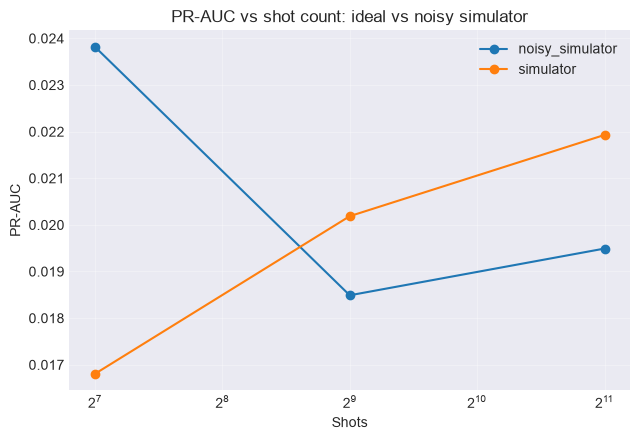

In [3]:
noise_df["pr_auc"] = pd.to_numeric(noise_df["pr_auc"])
noise_df["shots"] = pd.to_numeric(noise_df["shots"])

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for backend, group in noise_df.groupby("backend"):
    group = group.sort_values("shots")
    ax.plot(group["shots"], group["pr_auc"], marker="o", label=backend)
ax.set_xscale("log", base=2)
ax.set_xlabel("Shots"); ax.set_ylabel("PR-AUC")
ax.set_title("PR-AUC vs shot count: ideal vs noisy simulator")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\08_pr_auc_vs_shots.png")
plt.show()


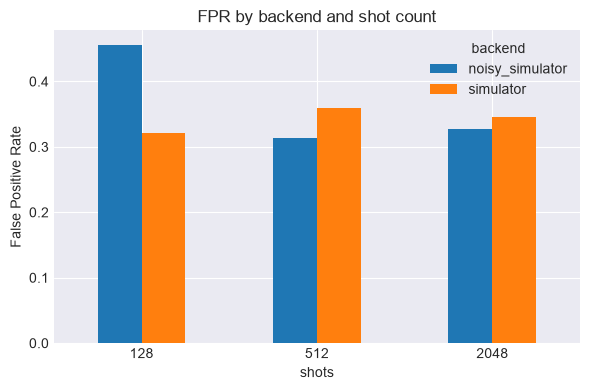

In [4]:
noise_df["fpr"] = pd.to_numeric(noise_df["fpr"])
fig, ax = plt.subplots(figsize=(6, 4))
pivot = noise_df.pivot_table(index="shots", columns="backend", values="fpr")
pivot.plot(kind="bar", ax=ax)
ax.set_ylabel("False Positive Rate")
ax.set_title("FPR by backend and shot count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(r"D:\Quantum Credit Card Fraud Detection\experiments\figures\08_fpr_by_backend.png")
plt.show()
